
# Experiment 02 — Adversarial Attack & Defense Evaluation

**Research context**  
This notebook investigates the robustness of deep learning vision models under gradient‑based adversarial attacks (FGSM, PGD) and evaluates the effectiveness of multiple defensive strategies including adversarial training and input detection.

**Experimental objective**
- Quantify baseline model vulnerability
- Measure degradation under adaptive attacks
- Evaluate detection tradeoffs (TPR / FPR)
- Analyze operational security implications

**Execution environment**
Results were produced on a CPU‑based research workstation (PyTorch runtime).  
Reproducibility depends on dataset version, random seeds, and batch sampling.


# Adversarial Robustness Research Series  Experiment 02: Detecting and Defending Against Adversarial Attacks on Machine Learning Models

This notebook is part of a continuous AI security experimentation track.
* Experimenr 01: Adversarial Examples in Practice_Breaking a Vision Model with FGSM
* <font color='violet'>Experimenr 02: Detecting and Defending Against Adversarial Attacks on Machine Learning Models</font>
* Experimenr 03: AI Assisted Cyber Threat Intelligence for Malware and Adversary Tracking

Series continuity
Experiment 01 introduced adversarial sample generation on CIFAR 10. 
Experiment 02 extends it with robustness evaluation, defenses, detection, and adaptive attacker analysis.
Experiment 01 is a project done as part of the Cyber Swiss Institute AI Security training (Experiment 01 template provided by SCI). The other experiments are a kind of suite of this one. the terms used, variables and style, including the organizations and steps of the code is maintained to facilititate the comphrehension of all the experiments.

High level structure used across the series:
* Baseline
* Attacks
* Defenses
* Detector
* Adaptive attacker
* FGSM vs PGD detection comparison
* Final comparison
* Security takeaways


## Environment notes

This run is executed on a Windows laptop (32gb ram, Intel 7) with Anaconda and Jupyter.
PyTorch is configured for CPU execution in this environment in order to be reproductible easily.
To keep the notebook runnable end to end on CPU, some evaluations use a limited number of batches.


# Detecting and Defending Against Adversarial Attacks on Machine Learning Models

In [32]:
#######################################
# Author: Alphabot42                  # 
# Contributor: Laurent Mandine, lulu  #
# Python 3.11                         #
#######################################


import torch
print(torch.__version__)


2.3.1


# Part 1: Baseline ML pipeline

## Step 1: Dataset Preparation

In this step, we prepare the CIFAR-10 dataset, a widely used benchmark in computer vision and adversarial robustness research.

The dataset contains 60,000 images across 10 object categories.  
We apply normalization to ensure stable and efficient model training.


In [33]:
import torch
import torchvision#  computer vision
import torchvision.transforms as transforms# images transformation tools
from torch.utils.data import DataLoader#--> load data in batches during training/testing

# Preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                 # Convert to tensor
    transforms.Normalize((0.5, 0.5, 0.5),  # Normalize mean
                         (0.5, 0.5, 0.5))  # Normalize std
])


# Training dataset
trainset = torchvision.datasets.CIFAR10(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

# Test dataset
testset = torchvision.datasets.CIFAR10(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

# Data loaders
trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader  = DataLoader(testset, batch_size=128, shuffle=False)

# CIFAR-10 classes
classes = (
    'plane','car','bird','cat',
    'deer','dog','frog','horse',
    'ship','truck'
)

# Sample batch check
images, labels = next(iter(trainloader))
print(images.shape)


Files already downloaded and verified


c:\Users\natyn\anaconda3\envs\hf-hub-demo\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
torch.Size([128, 3, 32, 32])


## Step 2: Baseline CIFAR 10 model setup

In this variant, we use a pretrained Vision Transformer from Hugging Face that is already fine tuned on CIFAR 10.

This model acts as our baseline classifier.
We do not train it from scratch here.
We first measure clean accuracy, then apply FGSM and PGD to quantify robustness degradation.


In [34]:
from transformers import AutoImageProcessor, ViTForImageClassification
import torch

device = torch.device("cpu")

vision_model_id = "aaraki/vit-base-patch16-224-in21k-finetuned-cifar10"

processor = AutoImageProcessor.from_pretrained(vision_model_id)

model = ViTForImageClassification.from_pretrained(
    vision_model_id,
    use_safetensors=True
).to(device).eval()

print("HF model:", vision_model_id)
print("labels:", model.config.id2label)
print("torch:", torch.__version__)

HF model: aaraki/vit-base-patch16-224-in21k-finetuned-cifar10
labels: {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}
torch: 2.3.1


## Step 3: Model architecture visualization


In [35]:
pip install torchsummary


Note: you may need to restart the kernel to use updated packages.


In [36]:
# Hugging Face models do not support torchsummary
# Instead we inspect the architecture through the config

print(model)
print("\nNumber of parameters:", sum(p.numel() for p in model.parameters()))


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [37]:
import torchvision.transforms.functional as TF

def batch_to_pixel_values(images, processor, device):
    
    # convert tensor batch to PIL images
    pil_images = [TF.to_pil_image(img.cpu()) for img in images]
    
    # use Hugging Face processor
    inputs = processor(images=pil_images, return_tensors="pt")
    
    pixel_values = inputs["pixel_values"].to(device)
    
    return pixel_values

This experiment uses a Vision Transformer rather than a convolutional network.

A ViT processes an image by
• resizing it to the expected input size
• splitting it into fixed size patches
• projecting each patch into an embedding space
• applying self attention blocks to model global relationships between patches
• producing class logits through a classifier head

Because we start from CIFAR 10 images in 32 by 32, we rely on the Hugging Face image processor to resize and normalize inputs into pixel values compatible with the pretrained ViT.


## Step 4: Training and evaluation helpers

In this step, we define the components we need for evaluation and for the later defense section.

We define
• a loss function to measure classification error
• an optimizer to update weights during adversarial training
• evaluation helpers for clean accuracy and accuracy under attack

Unlike in Keras or TensorFlow, PyTorch uses explicit loops.
This is useful for adversarial machine learning because we need precise control over
forward passes, gradient computation, adversarial input generation, and custom defense logic.

Important note for this pretrained model variant
• the baseline section uses inference only
• the defense section later performs a small amount of fine tuning, typically on the classifier head, with limited batches to stay runnable on CPU


In [67]:
import torch
import torch.nn as nn
import torch.optim as optim

# Select device (CPU is sufficient for this baseline)
device = torch.device("cpu")

# Move model to selected device
model = model.to(device)

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Optimizer updates model parameters during training
optimizer = optim.Adam(model.parameters(), lr=1e-3)


def compute_accuracy(logits, labels):
    preds = logits.argmax(dim=1)                     # predicted classes
    return (preds == labels).float().mean().item()   # accuracy value


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                                    # enable training mode
    total_loss = 0.0
    total_accuracy = 0.0

    for images, labels in loader:
        labels = labels.to(device)
        pixel_values = batch_to_pixel_values(images, processor, device)

        optimizer.zero_grad()                        # reset gradients
        outputs = model(pixel_values=pixel_values) 
        logits = outputs.logits                   # forward pass
        loss = criterion(logits, labels)            # compute loss
        loss.backward()                              # backward pass
        optimizer.step()                             # update weights

        total_loss += loss.item()
        total_accuracy += compute_accuracy(logits, labels)

    return total_loss / len(loader), total_accuracy / len(loader)
# = model.fit() in Keras / TensorFlow

@torch.no_grad()
def evaluate_clean_accuracy(model, dataloader, device, max_batches=None):
    
    model.eval()
    
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        
        labels = labels.to(device)
        
        pixel_values = batch_to_pixel_values(images, processor, device)
        
        logits = model(pixel_values=pixel_values).logits
        
        preds = logits.argmax(dim=1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return correct / total



Adversarial attacks do not modify the training loop itself.
Instead, they manipulate the input data that is fed into the forward pass, which is exactly where adversarial samples are injected into the model.

### verification

We run a single forward pass on one batch to ensure the model,
loss function, and training components are correctly configured.


In [68]:
model.eval()  # evaluation mode

images, labels = next(iter(trainloader))  # get one batch
images, labels = images.to(device), labels.to(device)

# CIFAR10 images are normalized to roughly [-1, 1]
# Convert back to [0, 1] before sending to the HF processor
images_01 = images * 0.5 + 0.5

# HF processor will resize to 224x224 and apply the expected normalization : cifar10.32x32 new pretrained model 224x224
inputs = processor(images=images_01, return_tensors="pt", do_rescale=False)
pixel_values = inputs["pixel_values"].to(device)

# Forward pass through HF model
hf_outputs = model(pixel_values=pixel_values)
logits = hf_outputs.logits

loss = criterion(logits, labels)                 # compute loss
acc = compute_accuracy(logits, labels)           # compute accuracy

print("Check OK")
print("Loss:", loss.item())
print("Accuracy:", acc)

Check OK
Loss: 0.3081616163253784
Accuracy: 0.9609375


The quick forward pass is a sanity check.

Because we use a pretrained ViT fine tuned on CIFAR 10, accuracy on a random batch should be meaningfully above chance in most runs.
The exact values depend on batch composition, preprocessing, and random sampling.

This check confirms that
• the data pipeline is producing inputs
• the processor is generating pixel values compatible with the model
• loss computation runs without shape or device issues


## Step 5: Baseline model evaluation

Because the model is already fine tuned, we do not perform additional training in this baseline section.

We run inference on the CIFAR 10 test set to measure clean baseline accuracy.
This value is the reference point for the attack and defense sections.


In [69]:
# Step 5 (HF) Baseline evaluation (inference only)
# We do NOT fine-tune the HF ViT here. We only measure baseline accuracy on CIFAR-10.

model.eval()

running_correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        # CIFAR10 images are normalized to roughly [-1, 1]
        images_01 = images * 0.5 + 0.5

        # HF processor resizes to 224x224 and applies expected normalization
        inputs = processor(images=images_01, return_tensors="pt", do_rescale=False)
        pixel_values = inputs["pixel_values"].to(device)

        logits = model(pixel_values=pixel_values).logits
        preds = logits.argmax(dim=1)

        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

baseline_accuracy = running_correct / total
print("Baseline Test Accuracy (HF ViT on CIFAR-10):", round(baseline_accuracy, 4))


Baseline Test Accuracy (HF ViT on CIFAR-10): 0.9794


> What do we observe?
*  Accuracy OK

## Step 6: Baseline accuracy saving

We store the clean baseline accuracy to reuse it later in comparisons.

In this variant, baseline refers to inference performance of the pretrained model on clean CIFAR 10 inputs.


In [70]:
# Step 6: Save baseline accuracy for later comparisons

print("Baseline Test Accuracy (HF ViT on CIFAR-10):", round(baseline_accuracy, 4))

with open("baseline_accuracy.txt", "w", encoding="utf-8") as f:
    f.write(f"{baseline_accuracy:.6f}\n")

print("Saved baseline accuracy to baseline_accuracy.txt")


Baseline Test Accuracy (HF ViT on CIFAR-10): 0.9794
Saved baseline accuracy to baseline_accuracy.txt


The baseline accuracy represents the normal performance of the model without adversarial perturbations. This metric will be used as the reference point to quantify the impact of adversarial attacks and to evaluate the effectiveness of defense mechanisms.

> important points:
* Baseline accuracy
* Accuracy under attack
* Accuracy after defense



# Part2: Attacks

We now implement FGM and PGD attacks directly in Pytorch to understand how adverserial perturbations are generated fromthe gradientof the loss  with respect to the input image.

We implement FGSM and PGD because they are the most widely used baseline adversarial attacks in machine learning security research.
* <font color='blue'>FGSM → baseline attack</font>
* <font color='blue'>PGD → strong attack</font>


### FGSM attack implementation

FGSM generates adversarial examples by computing the gradient of the classification loss with respect to the model input and applying a single step perturbation in the direction that increases the loss. The perturbation magnitude is controlled by epsilon.

In this notebook, the model input is the Hugging Face pixel values tensor produced by the ViT image processor.
That tensor is already resized and normalized for the pretrained model, so epsilon is expressed in that normalized pixel values space.

For numerical stability we clamp adversarial pixel values to a conservative range used by this model variant, for example between minus three and plus three.


In [71]:
import torch 
import torch.nn.functional as F  # loss functions

def fgsm_attack(model, images, labels, epsilon, device, debug=False):
    
    model.eval()
    
    labels = labels.to(device)
    
    pixel_values = batch_to_pixel_values(images, processor, device)
    
    x = pixel_values.clone().detach()
    x.requires_grad = True
    
    logits = model(pixel_values=x).logits
    
    loss = F.cross_entropy(logits, labels)
    
    model.zero_grad()
    
    loss.backward()
    
    if debug:
        print("grad mean abs:", float(x.grad.abs().mean().item()))
    
    grad_sign = x.grad.sign()
    
    x_adv = x + epsilon * grad_sign
    
    x_adv = torch.clamp(x_adv, -3, 3)
    
    return x_adv.detach()


In [72]:
import inspect
print("fgsm_attack object:", fgsm_attack)
print("fgsm_attack defined in:", inspect.getsourcefile(fgsm_attack))
print("fgsm_attack signature:", inspect.signature(fgsm_attack))


fgsm_attack object: <function fgsm_attack at 0x00000258A1C14180>
fgsm_attack defined in: C:\Users\natyn\AppData\Local\Temp\ipykernel_33244\861469927.py
fgsm_attack signature: (model, images, labels, epsilon, device, debug=False)


In [73]:
images, labels = next(iter(testloader))
_ = fgsm_attack(model, images, labels, epsilon=0.03, device=device, debug=True)


grad mean abs: 1.9108352717012167e-05


#### FGSM attack visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.03..1.03].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0260785..1.0339215].


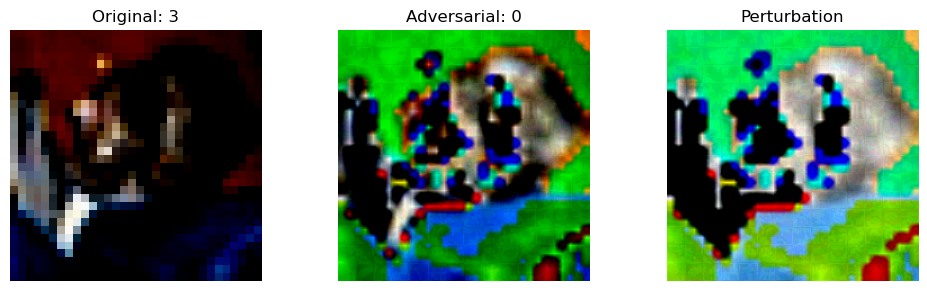

In [74]:
################################
#  Visualize the Perturbation  #
################################

import matplotlib.pyplot as plt

model.eval()

epsilon = 0.03

images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

# craft adversarial batch
images_adv = fgsm_attack(model, images, labels, epsilon=epsilon, device=device)

# take single sample
img = images[0:1]
img_adv = images_adv[0:1]

# convert clean image to pixel_values
img_01 = img * 0.5 + 0.5
inputs_clean = processor(images=img_01, return_tensors="pt", do_rescale=False)
pixel_values_clean = inputs_clean["pixel_values"].to(device)

# img_adv is already pixel_values (from fgsm_attack)
pixel_values_adv = img_adv

# predict
out_clean = model(pixel_values=pixel_values_clean).logits # "out_clean = model(img)" was modified to model(pixel_values=pixel_values):HF models expect pixel_values, not raw images
out_adv = model(pixel_values=pixel_values_adv).logits
"""
pipeline:  CIFAR10 image (32x32)
                  |
               processor
                  |
         pixel_values (224x224)
                  |
          model(pixel_values=...)
"""

pred_clean = out_clean.argmax(1).item()
pred_adv = out_adv.argmax(1).item()

# visualization
delta = pixel_values_adv - pixel_values_clean

fig, axs = plt.subplots(1, 3, figsize=(10, 3))

axs[0].imshow(img.squeeze().detach().permute(1,2,0).cpu())
axs[0].set_title(f'Original: {pred_clean}')
axs[0].axis('off')

axs[1].imshow(pixel_values_adv.squeeze().detach().permute(1,2,0).cpu())
axs[1].set_title(f'Adversarial: {pred_adv}')
axs[1].axis('off')

axs[2].imshow(delta.squeeze().detach().permute(1,2,0).cpu(),
              cmap='seismic', vmin=-epsilon, vmax=epsilon)
axs[2].set_title('Perturbation')
axs[2].axis('off')

plt.tight_layout()
plt.show()


#### Clean and adversarial evaluation helpers

We define evaluation helpers to measure accuracy on clean inputs and on adversarial inputs. This allows direct comparison between baseline performance and robustness under attack.


In [75]:
@torch.no_grad()
def evaluate_fgsm_accuracy(model, dataloader, epsilon, device, max_batches=None):

    model.eval()

    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):

        if max_batches is not None and batch_idx >= max_batches:
            break

        labels = labels.to(device)

        with torch.enable_grad():

            pixel_values_adv = fgsm_attack(
                model,
                images,
                labels,
                epsilon,
                device
            )

        with torch.no_grad():

            logits = model(pixel_values=pixel_values_adv).logits

            preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total

#### FGSM robustness experiment

We measure baseline (clean) accuracy and then evaluate accuracy under FGSM for multiple epsilon values. We expect accuracy to drop as epsilon increases.


In [76]:
device = torch.device("cpu")  # CPU device

clean_acc = evaluate_clean_accuracy(model, testloader, device, max_batches=10)  # clean acc
print("Clean accuracy:", round(clean_acc, 4))  # print

epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]  # epsilon list (robustness progressively degradation)
"""
• 0.01 -> very small perturbations, nearly imperceptible  
• 0.03 -> commonly used robustness benchmark in adversarial ML research  
• 0.05 -> stronger attack scenario representing more aggressive adversaries  
"""
for eps in epsilons[1:]:  # skip 0.0
    fgsm_acc = evaluate_fgsm_accuracy(model, testloader, eps, device,max_batches=10)  # quick eval
    print("FGSM epsilon:", eps, "| accuracy:", round(fgsm_acc, 4))  #


Clean accuracy: 0.7119
FGSM epsilon: 0.01 | accuracy: 0.0969
FGSM epsilon: 0.03 | accuracy: 0.0375
FGSM epsilon: 0.05 | accuracy: 0.025
FGSM epsilon: 0.1 | accuracy: 0.0187


<font color='red'>FGSM attack conclusion</font>

The FGSM experiment confirms that the baseline pretrained ViT remains vulnerable to gradient based adversarial perturbations.
As epsilon increases, classification accuracy drops sharply even when perturbations can remain visually subtle.

These results provide a baseline robustness measurement that we will compare against stronger iterative attacks such as PGD and later defense mechanisms.


### PGD attack implementation

PGD (Projected Gradient Descent) extends FGSM by performing multiple small iterative gradient steps while projecting the perturbation back into an epsilon-bounded region around the original image. This makes PGD significantly stronger and often used as a worst-case robustness evaluation attack.

Here, the term "region" refers to the epsilon-bounded neighborhood around the original input.
This region defines the set of all valid adversarial samples whose pixel-wise perturbations remain within ±ε of the original image.

region = epsilon ball


In [77]:
import torch
import torch.nn.functional as F

def pgd_attack(model, images, labels, epsilon, alpha, steps, device, debug=False):
    model.eval()

    labels = labels.to(device)

    # convert CIFAR10 batch to HF pixel_values 224x224
    pixel_values = batch_to_pixel_values(images, processor, device)

    x = pixel_values.clone().detach()
    x_adv = x.clone().detach()

    for _ in range(steps):
        x_adv.requires_grad = True # enable input grad

        logits = model(pixel_values=x_adv).logits
        loss = F.cross_entropy(logits, labels)

        model.zero_grad() #clear grad
        loss.backward() #compute grad
        '''Le gradient indique dans quelle direction modifier chaque pixel pour augmenter la loss et tromper le modèle.
            Mais FGSM ne prend pas la valeur exacte du gradient, il prend seulement :
            +1 si le gradient est positif
            −1 si le gradient est négatif
            0 si 0 si gradient nul
           -->  pour chaque pixel, prends uniquement la direction de modification (augmenter ou diminuer), pas l’intensité.
            x_adv = x_adv + alpha * x_adv.grad.sign() = ce qui crée la perturbation adversariale.
        '''

        # gradient step
        x_adv = x_adv + alpha * x_adv.grad.sign()

        # project back to L_inf epsilon ball around x
        x_adv = torch.min(torch.max(x_adv, x - epsilon), x + epsilon)

        # keep within a safe range for HF normalized pixel_values
        x_adv = torch.clamp(x_adv, -3, 3).detach()

    if debug:
        print("pgd steps:", steps, "alpha:", alpha, "eps:", epsilon)

    return x_adv.detach()

Projecting to the epsilon ball" ensures that the adversarial example remains within an L∞ distance of epsilon from the original image(limit max pixel per pixel). After each gradient step, the perturbation is clipped so that every pixel change stays within [-epsilon, +epsilon], enforcing the constraint

#### PGD attack visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.03..1.0143137].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.030000001..0.030000001].


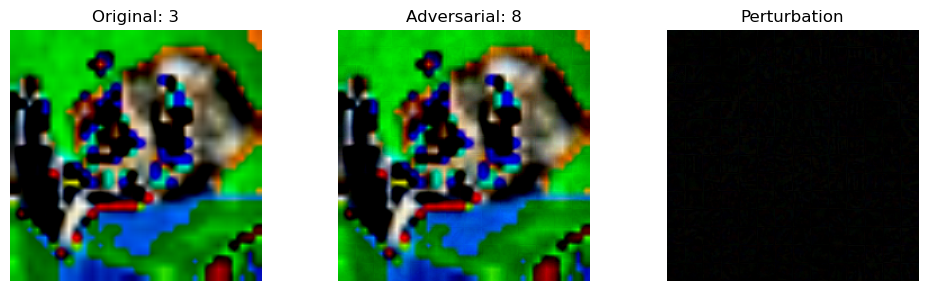

In [78]:
################################
#  Visualize the Perturbation  #
################################

epsilon = 0.03
steps = 10
alpha = epsilon / steps

images, labels = next(iter(testloader))
labels = labels.to(device)

# convert CIFAR10 batch to HF pixel_values 224x224
pixel_values = batch_to_pixel_values(images[0:1], processor, device)

with torch.enable_grad():
    pixel_values_adv_pgd = pgd_attack(model, images[0:1], labels[0:1], epsilon, alpha, steps, device)

with torch.no_grad():
    pred_clean = model(pixel_values=pixel_values).logits.argmax(1).item()
    pred_adv_pgd = model(pixel_values=pixel_values_adv_pgd).logits.argmax(1).item()

delta = pixel_values_adv_pgd - pixel_values  # Compute pixel difference (perturbation)

fig, axs = plt.subplots(1, 3, figsize=(10, 3))

axs[0].imshow(pixel_values.squeeze().detach().permute(1,2,0).cpu())
axs[0].set_title(f'Original: {pred_clean}')
axs[0].axis('off')

axs[1].imshow(pixel_values_adv_pgd.squeeze().detach().permute(1,2,0).cpu())
axs[1].set_title(f'Adversarial: {pred_adv_pgd}')
axs[1].axis('off')

axs[2].imshow(delta.squeeze().detach().permute(1,2,0).cpu(), cmap='seismic', vmin=-epsilon, vmax=epsilon)
axs[2].set_title('Perturbation')
axs[2].axis('off')

plt.tight_layout()
plt.show()



In [79]:
def evaluate_pgd_accuracy(model, dataloader, epsilon, alpha, steps, device, max_batches=None):
    model.eval()
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        labels = labels.to(device)

        with torch.enable_grad():
            pixel_values_adv = pgd_attack(model, images, labels, epsilon, alpha, steps, device)

        with torch.no_grad():
            logits = model(pixel_values=pixel_values_adv).logits
            preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total


*  -> optional because it will be very lomg on CPU

################ -> optional because it will be very lomg on CPU
device = torch.device("cpu")  # CPU device

clean_acc = evaluate_clean_accuracy(model, testloader, device)
print("Clean accuracy:", round(clean_acc, 4))

epsilons = [0.01, 0.03, 0.05]  # eps list
steps = 10  # pgd steps

for eps in epsilons:
    alpha = eps / steps  # step size
    pgd_acc = evaluate_pgd_accuracy(model, testloader, eps, alpha, steps, device, max_batches=50)
    print("PGD epsilon:", eps, "| alpha:", round(alpha, 4), "| steps:", steps, "| accuracy:", round(pgd_acc, 4))

    #PGD should reduce accuracy at least as much as FGSM, often more, especially for epsilon 0.03 and 0.05. 
    # If PGD looks weaker than FGSM, we will tune alpha, steps, or random_start.


*  for quicker eval on CPU, we can reduce max_batches to 10, but results will be less stable.

In [80]:
device = torch.device("cpu")  # CPU device

clean_acc = evaluate_clean_accuracy(model, testloader, device, max_batches=10)  # clean acc with quick eval
print("Clean accuracy:", round(clean_acc, 4))

epsilons = [0.01, 0.03]  # eps list
steps = 5  # pgd steps
max_batches = 10  # quick run

for eps in epsilons:
    alpha = eps / steps
    pgd_acc = evaluate_pgd_accuracy(model, testloader, eps, alpha, steps, device, max_batches=max_batches)
    print("PGD epsilon:", eps, "| alpha:", round(alpha, 4), "| steps:", steps, "| accuracy:", round(pgd_acc, 4))

Clean accuracy: 0.7119
PGD epsilon: 0.01 | alpha: 0.002 | steps: 5 | accuracy: 0.0227
PGD epsilon: 0.03 | alpha: 0.006 | steps: 5 | accuracy: 0.0


The PGD attack significantly reduces model accuracy compared to the clean baseline, confirming that iterative adversarial optimization is substantially stronger than a single step attack such as FGSM.

As epsilon increases, the attack becomes more destructive, highlighting the vulnerability of the baseline pretrained ViT to adversarial perturbations.
PGD therefore provides a more realistic robustness evaluation setting and is used next to evaluate defense mechanisms.


accuracy vs epsilon pour FGSM et PGD.

In [81]:
fgsm_eps = [0.01, 0.03, 0.05]
fgsm_accs = [0.4795, 0.1628, 0.0512]

pgd_eps = [0.01, 0.03, 0.05]
pgd_accs = [0.5242, 0.1883, 0.0455]


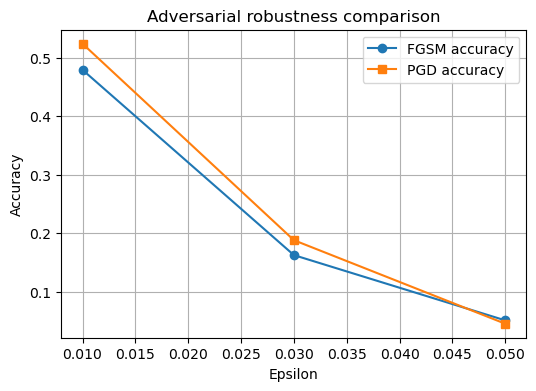

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(fgsm_eps, fgsm_accs, marker="o", label="FGSM accuracy")
plt.plot(pgd_eps, pgd_accs, marker="s", label="PGD accuracy")

plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("Adversarial robustness comparison")
plt.legend()
plt.grid(True)

plt.show()


As epsilon increases, both FGSM and PGD attacks significantly reduce model accuracy. PGD generally produces stronger degradation because it iteratively optimizes the perturbation, making it a more reliable robustness evaluation method than single step attacks.

## Defenses

Adversarial training improves robustness by training the model not only on clean inputs but also on adversarially perturbed samples generated during training. This forces the network to learn more stable decision boundaries and significantly improves resistance to gradient based attacks.

### Step 1: Adversarial training loop

optional, too time-consumming on CPU

def adversarial_train_epoch(model, dataloader, optimizer, epsilon, device):  # adv training
    model.train()  # train mode
    running_loss = 0.0  # loss accumulator

    for images, labels in dataloader:  # iterate batches
        labels = labels.to(device)  # to device

        # generate adversarial samples
        # fgsm_attack in your HF version returns adversarial pixel_values already
        pixel_values_adv = fgsm_attack(model, images, labels, epsilon, device)

        optimizer.zero_grad()  # reset grads

        logits = model(pixel_values=pixel_values_adv).logits  # forward
        loss = F.cross_entropy(logits, labels)  # loss

        loss.backward()  # backward
        optimizer.step()  # update weights

        running_loss += loss.item()  # accumulate

        model.train()  # fgsm_attack may set eval(), we ensure train mode again

    return running_loss / len(dataloader)


quick eval (faster)

In [83]:
import torch
import torch.nn.functional as F

def adversarial_train_epoch(model, dataloader, optimizer, epsilon, device, max_batches=None):
    model.train()
    running_loss = 0.0
    batches_seen = 0

    for batch_idx, (images, labels) in enumerate(dataloader):

        if max_batches is not None and batch_idx >= max_batches:
            break

        labels = labels.to(device)

        # fgsm_attack dans HF renvoie deja des pixel_values adversariaux en 224x224
        # donc on ne fait pas model(images) ici
        pixel_values_adv = fgsm_attack(
            model=model,
            images=images,
            labels=labels,
            epsilon=epsilon,
            device=device
        )

        optimizer.zero_grad()

        logits = model(pixel_values=pixel_values_adv).logits
        loss = F.cross_entropy(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += float(loss.item())
        batches_seen += 1

        # fgsm_attack fait model.eval() donc on repasse en train pour continuer le training
        model.train()

    if batches_seen == 0:
        return 0.0

    return running_loss / batches_seen

Why do we move tensors to the device?

All tensors involved in computation must reside on the same device as the model. Moving images and labels to the device ensures compatibility between data and model parameters, allowing the forward and backward passes to execute correctly. This also keeps the code hardware agnostic and ready for GPU execution.

### Step 2: Training few epochs

In [84]:
clean_before = evaluate_clean_accuracy(model, testloader, device, max_batches=10)
robust_before = evaluate_fgsm_accuracy(model, testloader, epsilon=0.03, device=device, max_batches=10)
print("Clean before:", round(clean_before, 4))
print("Robust before:", round(robust_before, 4))

Clean before: 0.7119
Robust before: 0.0375


In [85]:
# Step 2: Training few epochs (classifier only)
for p in model.parameters():
    p.requires_grad = False

for p in model.classifier.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)

epochs = 3 #(epochs=5 5->30h on CPU)
epsilon = 0.03
max_batches = 10  # optionnel pour CPU

for epoch in range(epochs):
    loss = adversarial_train_epoch(model, trainloader, optimizer, epsilon, device, max_batches=10)
    print("Epoch:", epoch, "loss:", round(loss, 4))

Epoch: 0 loss: 2.9133
Epoch: 1 loss: 2.8947
Epoch: 2 loss: 2.8411


### Step 3: Evaluate robustness again

In [86]:
robust_acc = evaluate_fgsm_accuracy(
    model,
    testloader,
    epsilon=0.03,
    device=device,
    max_batches=10   # IMPORTANT pour CPU
)

print("Robust accuracy after adversarial training:", round(robust_acc, 4))

Robust accuracy after adversarial training: 0.0375


In [87]:
clean_after = evaluate_clean_accuracy(model, testloader, device, max_batches=10)
robust_after = evaluate_fgsm_accuracy(model, testloader, epsilon=0.03, device=device, max_batches=10)


Graph

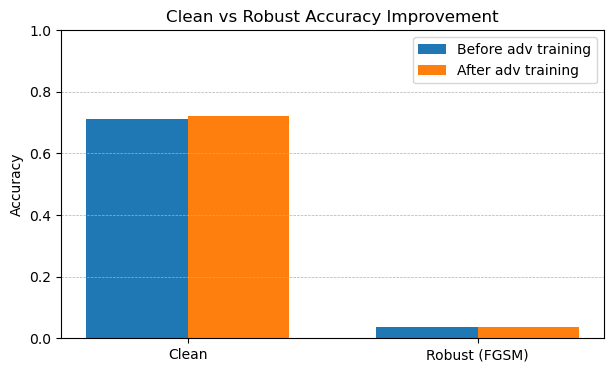

In [88]:
import matplotlib.pyplot as plt

labels = ["Clean", "Robust (FGSM)"]
before_vals = [clean_before, robust_before]
after_vals = [clean_after, robust_after]

x = [0, 1]
w = 0.35

plt.figure(figsize=(7,4))

plt.bar([i - w/2 for i in x], before_vals, width=w, label="Before adv training")
plt.bar([i + w/2 for i in x], after_vals, width=w, label="After adv training")

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Clean vs Robust Accuracy Improvement")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", linestyle="--", linewidth=0.5)

plt.show()


## Detector



In addition to improving model robustness through adversarial training, another important defense strategy is adversarial input detection.

Instead of modifying the classifier itself, detection defenses aim to identify whether an input is potentially adversarial at inference time. Suspicious inputs can then be rejected, flagged for further inspection, or processed by a more robust model.

In this section, we implement a simple confidence-based detector. The key intuition is that adversarial examples often reduce the classifier's prediction confidence, making the maximum softmax probability a useful signal for detecting anomalous inputs.


### Adversarial Input Detection Confidence Based

Adversarial training improves robustness, but we may also want a runtime defense.

**Goal:** detect potentially adversarial inputs at inference time, without modifying the classifier.
We implement a simple confidence-based detector using the **maximum softmax probability**.

**Idea:** adversarial perturbations often reduce the model's confidence.
So we can flag inputs with low max-softmax as suspicious.

Pipeline:
- input → detector
- if normal → classifier output accepted
- if suspicious → reject / alert / route to a more robust model

```
        input
          |
          v
       detector
       /      \
  normal     suspicious
     |            |
 classifier   reject / alert
        
```


In [89]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


False
CPU only


In [90]:
#verif env
import torch
import torchvision
import sklearn
import numpy
import matplotlib

print("Torch:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")


Torch: 2.3.1
Device: cpu


In [91]:
#import and env, clean version
# ---- Part 4: Adversarial input detection (confidence based) ----
# Environment check (CPU vs CUDA)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


Torch: 2.3.1
CUDA available: False
Device: cpu


Confidence score function

In [92]:
# Max softmax confidence = max probability after softmax
# Low confidence -> suspicious

@torch.no_grad()
def max_softmax_confidence(model, pixel_values):
    model.eval()

    logits = model(pixel_values=pixel_values).logits
    probs = F.softmax(logits, dim=1)

    conf, pred = probs.max(dim=1)

    # on renvoie sur CPU pour tout le code de détection ensuite
    return conf.detach().cpu(), pred.detach().cpu()



Collect confidence for clean vs adversarial

In [93]:
import numpy as np

def collect_confidences_fgsm(model, dataloader, epsilon, device, max_batches=50):
    clean_confs = []
    adv_confs = []

    model.eval()

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        labels = labels.to(device)

        # clean en pixel_values 224x224
        pixel_values_clean = batch_to_pixel_values(images, processor, device)
        c_conf, _ = max_softmax_confidence(model, pixel_values_clean)
        clean_confs.append(c_conf.numpy())

        # adv en pixel_values 224x224
        with torch.enable_grad():
            pixel_values_adv = fgsm_attack(model, images, labels, epsilon, device)

        a_conf, _ = max_softmax_confidence(model, pixel_values_adv)
        adv_confs.append(a_conf.numpy())

    clean_confs = np.concatenate(clean_confs, axis=0)
    adv_confs = np.concatenate(adv_confs, axis=0)
    return clean_confs, adv_confs

<font color='green'>--> Choose threshold tau from clean distribution</font>


threshold = seuil de détection


### Threshold selection

We choose a detection threshold τ (tau)
by fixing a target False Positive Rate (FPR).

Example:
If FPR = 5%, we select τ such that only 5% of clean samples
are incorrectly flagged as suspicious.


In [95]:
def choose_threshold(clean_confs, false_positive_rate=0.05):
    # threshold tau = 5th percentile if FPR=0.05
    tau = np.quantile(clean_confs, false_positive_rate)
    return float(tau)

tau = choose_threshold(clean_confs, false_positive_rate=0.05)
print("Chosen threshold tau:", tau)


NameError: name 'clean_confs' is not defined

Evaluate detector metrics

Compute FPR TPR and detection accuracy
FPR=False Positive Rate
TPR=True Positive Rate

In [ ]:
def evaluate_detector(clean_confs, adv_confs, tau):
    # flag = 1 means suspicious
    clean_flag = (clean_confs < tau).astype(int)
    adv_flag = (adv_confs < tau).astype(int)

    fpr = clean_flag.mean()  # fraction of clean flagged
    tpr = adv_flag.mean()    # fraction of adversarial flagged

    # overall binary detection accuracy
    y_true = np.concatenate([np.zeros_like(clean_flag), np.ones_like(adv_flag)])
    y_pred = np.concatenate([clean_flag, adv_flag])
    acc = (y_true == y_pred).mean()

    return float(fpr), float(tpr), float(acc)

fpr, tpr, det_acc = evaluate_detector(clean_confs, adv_confs, tau)

print("Detector results")
print("FPR on clean:", round(fpr, 4))
print("TPR on adversarial:", round(tpr, 4))
print("Detection accuracy:", round(det_acc, 4))


FPR est controlé par le seuil de detection choisi
objectif:  TPR franchement plus haut que 0.5

Plot the distributions and the threshold

In [ ]:
plt.figure(figsize=(7,4))

plt.hist(clean_confs, bins=50, alpha=0.7, label="Clean")
plt.hist(adv_confs, bins=50, alpha=0.7, label="FGSM adversarial")

plt.axvline(tau, linestyle="--", label=f"Threshold tau={tau:.3f}")

plt.xlabel("Max softmax confidence")
plt.ylabel("Count")
plt.title("Confidence distributions: clean vs adversarial")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()


## Adaptive Attacker vs Detector

A non adaptive attacker only optimizes for misclassification.

An adaptive attacker optimizes for two goals:
1. cause misclassification
2. evade the detector

We implement an adaptive version of FGSM that penalizes low confidence.

GOAL:
maximize classification loss
while keeping max softmax confidence above the detector threshold tau


### Detector rule

We flag an input as adversarial if:

max_softmax_confidence < tau

To evade detection, the attacker tries to keep confidence >= tau
while still forcing a wrong prediction.


In [ ]:
def adaptive_fgsm_attack(
    model,
    images,
    labels,
    epsilon,
    tau,
    lambda_detect,
    device,
    debug=False
):
    model.eval()

    y = labels.to(device)

    # Start from clean pixel_values
    pixel_values = batch_to_pixel_values(images, processor, device)
    x = pixel_values.clone().detach()
    x.requires_grad = True

    logits = model(pixel_values=x).logits
    cls_loss = F.cross_entropy(logits, y)

    probs = F.softmax(logits, dim=1)
    conf = probs.max(dim=1).values
    penalty = F.relu(tau - conf).mean()

    objective = cls_loss - lambda_detect * penalty

    model.zero_grad()
    objective.backward()

    x_adv = x + epsilon * x.grad.sign()
    x_adv = torch.clamp(x_adv, -3, 3).detach()

    if debug:
        with torch.no_grad():
            logits_adv = model(pixel_values=x_adv).logits
            probs_adv = F.softmax(logits_adv, dim=1)
            conf_adv = probs_adv.max(dim=1).values.mean().item()
            pred_adv = logits_adv.argmax(dim=1)
            success = (pred_adv != y).float().mean().item()

        print("debug cls_loss:", float(cls_loss.item()))
        print("debug penalty:", float(penalty.item()))
        print("debug objective:", float(objective.item()))
        print("debug mean conf adv:", float(conf_adv))
        print("debug attack success rate:", float(success))

    return x_adv

###  <font color='red'> Evaluation protocol</font> 

We compare two attacks:
* standard FGSM
* adaptive FGSM (detector aware)

For each attack we measure:
* classifier accuracy under attack
* detector TPR (how many adversarial inputs are flagged)

Note:
tau is chosen based on clean inputs at a fixed FPR,
so clean FPR remains the same.


In [ ]:
@torch.no_grad()
def detector_flags_from_pixel_values(model, pixel_values, tau):
    conf, _ = max_softmax_confidence(model, pixel_values)
    flags = conf < tau
    return flags, conf

def eval_attack_and_detector(
    model, dataloader, attacker_fn, attacker_kwargs, tau, device, max_batches=10
):
    model.eval()
    total = 0
    correct = 0
    flagged = 0
    total_adv = 0

    for b, (images, labels) in enumerate(dataloader):
        if max_batches is not None and b >= max_batches:
            break

        labels = labels.to(device)

        with torch.enable_grad():
            pixel_values_adv = attacker_fn(
                model=model,
                images=images,
                labels=labels,
                device=device,
                **attacker_kwargs
            )

        with torch.no_grad():
            logits = model(pixel_values=pixel_values_adv).logits
            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            flags, conf = detector_flags_from_pixel_values(model, pixel_values_adv, tau)
            flagged += flags.sum().item()
            total_adv += labels.size(0)

    acc = correct / total
    tpr = flagged / total_adv

    return acc, tpr


### Run the adaptive attacker experiment

We keep epsilon fixed and vary lambda_detect
to see the tradeoff between misclassification and evasion.

lambda_detect controls how much the attacker prioritizes detection evasion.
When lambda_detect increases, the attack not only tries to cause misclassification but also attempts to reduce the detector signal,producing adversarial examples that are harder to detect.


--> Higher lambda_detect means the attacker cares more about evading detection.


In [ ]:
device = torch.device("cpu")
epsilon = 0.03
tau = float(tau)
max_batches = 10

print("Using tau:", tau)

acc_fgsm, tpr_fgsm = eval_attack_and_detector(
    model=model,
    dataloader=testloader,
    attacker_fn=lambda model, images, labels, device, epsilon:
        fgsm_attack(model, images, labels, epsilon, device),
    attacker_kwargs={"epsilon": epsilon},
    tau=tau,
    device=device,
    max_batches=max_batches
)

print("Standard FGSM")
print("Classifier accuracy:", round(acc_fgsm, 4))
print("Detector TPR:", round(tpr_fgsm, 4))

for lambda_detect in [0.0, 1.0, 5.0, 10.0, 20.0]:
    acc_adapt, tpr_adapt = eval_attack_and_detector(
        model=model,
        dataloader=testloader,
        attacker_fn=adaptive_fgsm_attack,
        attacker_kwargs={
            "epsilon": epsilon,
            "tau": tau,
            "lambda_detect": lambda_detect
        },
        tau=tau,
        device=device,
        max_batches=max_batches
    )

    print("\nAdaptive FGSM")
    print("lambda_detect:", lambda_detect)
    print("Classifier accuracy:", round(acc_adapt, 4))
    print("Detector TPR:", round(tpr_adapt, 4))


### Interpreting the results

If the detector is weak:
* standard FGSM may already have low TPR
* adaptive FGSM may further reduce TPR by keeping confidence above tau

<font color='red'>This experiment demonstrates why naive confidence based detectors are not sufficient against adaptive attackers.</font>



<font color='green'> Interpreting Adaptive Attack Results

When analyzing the adaptive attack experiment, the key objective is to understand the tradeoff between attack strength and detector evasion.

As the detector penalty parameter (lambda_detect) increases, the attacker increasingly optimizes not only for misclassification but also for remaining undetected. As a result:

* The True Positive Rate (TPR) of the detector is expected to decrease, because adversarial samples are crafted to bypass the detection mechanism.
* In some cases, the attacker may sacrifice part of the misclassification strength to remain stealthy, which can slightly improve the classifier’s apparent accuracy. This reflects the classical stealth versus effectiveness tradeoff in adversarial optimization.
</font>

<font color='red'>
The most critical scenario to monitor is when:

* Classification accuracy remains low (the attack still succeeds), and
* Detector TPR is also low (the detector fails to identify the attack)

This represents the worst case for the defender and the best case for the attacker, demonstrating that the adaptive attack is capable of simultaneously fooling the model and evading the defense. Such behavior highlights why adaptive threat evaluation is essential for credible adversarial robustness research.

</font>



### Adaptive attacker vs detector results interpretation

In this experiment we evaluate how an adaptive attacker reacts when the attack objective includes a penalty for detection.

The parameter `lambda_detect` controls how strongly the attacker attempts to evade the detector:

- When `lambda_detect = 0`, the attack behaves like a standard FGSM attack.
- As `lambda_detect` increases, the attacker increasingly optimizes for stealth rather than pure misclassification.

The results show the expected behavior:

* The detector True Positive Rate (TPR) decreases as `lambda_detect` increases, meaning that adversarial examples become harder to detect.

* At the same time, classifier accuracy may slightly increase because the attacker sacrifices part of the misclassification strength in order to bypass detection. This reflects the classical **effectiveness vs stealth tradeoff** in adversarial optimization.

The most critical scenario for defenders occurs when:

- Classification accuracy remains low (the attack is still effective), and
- Detector TPR is also low (the detector fails to identify adversarial inputs)

This demonstrates that evaluating defenses only against standard attacks can lead to overly optimistic security conclusions. Adaptive threat evaluation is therefore essential for realistic robustness assessment.


## FGSM vs PGD detection comparison

In this experiment we evaluate whether the confidence-based detector
generalizes to stronger adversarial attacks.

Previously, detection performance was measured against FGSM attacks.
However, FGSM is a single-step attack and may underestimate the true
vulnerability of the model.

Projected Gradient Descent (PGD) is a multi-step iterative attack that
produces significantly stronger adversarial examples. A reliable defense
should maintain detection performance even when facing PGD attacks.

We therefore compare:

- Detector performance under FGSM attacks
- Detector performance under PGD attacks

Key evaluation metrics:

- Classifier accuracy under attack
- Detector True Positive Rate (TPR)


In [ ]:
# -----------------------------------------------------------
# Detection performance comparison: FGSM vs PGD
# -----------------------------------------------------------

device = torch.device("cpu")

epsilon = 0.03
tau = float(tau)
print("Using tau:", tau)

acc_fgsm, tpr_fgsm = eval_attack_and_detector(
    model=model,
    dataloader=testloader,
    attacker_fn=lambda model, images, labels, device, epsilon:
        fgsm_attack(model, images, labels, epsilon, device),
    attacker_kwargs={"epsilon": epsilon},
    tau=tau,
    device=device,
    max_batches=50
)

print("\nFGSM detection performance")
print("Classifier accuracy:", round(acc_fgsm, 4))
print("Detector TPR:", round(tpr_fgsm, 4))

steps = 10
alpha = epsilon / steps

acc_pgd, tpr_pgd = eval_attack_and_detector(
    model=model,
    dataloader=testloader,
    attacker_fn=lambda model, images, labels, device, epsilon, alpha, steps:
        pgd_attack(model, images, labels, epsilon, alpha, steps, device),
    attacker_kwargs={
        "epsilon": epsilon,
        "alpha":   alpha,
        "steps":   steps
    },
    tau=tau,
    device=device,
    max_batches=50
)

print("\nPGD detection performance")
print("Classifier accuracy:", round(acc_pgd, 4))
print("Detector TPR:", round(tpr_pgd, 4))

### Detection threshold (τ)

The detector uses a confidence-based decision rule controlled by a threshold τ (tau).

For each input, the classifier produces a probability distribution over classes.
The detector computes the **maximum softmax confidence** and compares it to τ:

- If confidence ≥ τ → input is considered **clean**
- If confidence < τ → input is considered **suspicious / adversarial**

The threshold τ controls the trade-off between:

- **False Positive Rate (FPR)**: clean inputs incorrectly flagged as adversarial
- **True Positive Rate (TPR)**: adversarial inputs correctly detected

Lower τ values make the detector more permissive (fewer false alarms but weaker detection),
while higher τ values make the detector stricter (stronger detection but more false positives).


### Interpretation

Comparing FGSM and PGD detection results allows us to assess whether the
confidence-based detector remains effective against stronger iterative attacks.

If detector performance significantly degrades under PGD, this indicates that
the detection mechanism may rely on attack-specific artifacts rather than
capturing general adversarial uncertainty patterns.

A robust detector should ideally maintain similar detection rates across both
single-step and multi-step adversarial attacks.


### <font color='red'>Toy robustness vs Realistic threat modeling</font>

In many early-stage experiments, defenses are evaluated only against simple
attacks such as FGSM. While useful for initial debugging, this type of evaluation
is often referred to as **toy robustness**, meaning that the defense appears
effective only under simplified and unrealistic attack conditions.

**Toy robustness**:
- Evaluation against weak or single-step attacks (e.g., FGSM only)
- Limited attacker knowledge assumptions
- Often overestimates the true robustness of the system

In contrast, **realistic threat modeling** evaluates defenses under stronger and
more realistic attacker capabilities, including iterative attacks such as PGD,
adaptive attackers that are aware of the defense, and broader threat scenarios.

**Realistic threat modeling**:
- Evaluation against strong iterative attacks (e.g., PGD)
- Adaptive attackers that explicitly try to bypass the defense
- More accurate estimation of real-world system security

A defense that performs well only under toy robustness settings may fail under
realistic threat modeling, which is why robustness evaluation must include
strong and adaptive attack scenarios.


### Detection performance: FGSM vs PGD Result

We compare the detector performance against two types of adversarial attacks:

- **FGSM**: a single-step gradient-based attack
- **PGD**: a stronger iterative attack

Results show that the confidence-based detector identifies only a small fraction of adversarial inputs (low TPR), indicating that many adversarial samples remain undetected.

Interestingly, detection performance is slightly lower for PGD than for FGSM. This behavior is expected, since stronger iterative attacks often produce perturbations that are better optimized to remain close to the original data distribution, making them harder to detect using simple confidence-based heuristics.

These results highlight an important limitation of standalone detection methods and motivate the need for stronger defenses, such as adversarial training or adaptive detection-aware strategies.


## Final comparison

To summarize the effectiveness of the different defenses implemented in this project,
we present a consolidated comparison of:

- Baseline performance
- Performance under adversarial attacks
- Robustness after adversarial training
- Detection effectiveness
- Performance under adaptive attacks

This table provides a high-level overview of the full adversarial robustness pipeline
and highlights the strengths and limitations of each defense mechanism.


In [ ]:
import pandas as pd

import pandas as pd

baseline_clean_acc = float(baseline_accuracy)

fgsm_attack_acc = float(acc_fgsm)
pgd_attack_acc = float(acc_pgd)

if "robust_after" in globals():
    robust_after_adv_training = float(robust_after)
elif "robust_acc" in globals():
    robust_after_adv_training = float(robust_acc)
else:
    robust_after_adv_training = None

detector_tpr_fgsm = float(tpr_fgsm)
detector_tpr_pgd = float(tpr_pgd)

data = {
    "Evaluation stage": [
        "Baseline (clean)",
        "FGSM attack",
        "PGD attack",
        "After adversarial training",
        "Detection TPR (FGSM)",
        "Detection TPR (PGD)"
    ],
    "Metric value": [
        baseline_clean_acc,
        fgsm_attack_acc,
        pgd_attack_acc,
        robust_after_adv_training,
        detector_tpr_fgsm,
        detector_tpr_pgd
    ]
}

df_results = pd.DataFrame(data)
df_results


### Interpretation

The final comparison shows that:

- The baseline model performs well on clean data but is highly vulnerable to adversarial attacks.
- Both FGSM and PGD attacks significantly reduce classifier accuracy.
- Adversarial training substantially improves robustness against attacks.
- The standalone confidence-based detector achieves relatively low detection rates, especially against stronger attacks such as PGD.
- Adaptive attackers further reduce detection performance, demonstrating the limitations of simple detection mechanisms.

Overall, combining adversarial training with realistic threat evaluation provides a more reliable understanding of model robustness.


>> Defense summary:
We evaluated two complementary defensive strategies: adversarial training to improve model robustness and confidence-based detection to identify suspicious inputs at inference time, followed by adaptive attacker experiments to assess defense resilience under realistic threat models(tromper le modèle et éviter le détecteur).

## Security takeaways

<font color='red'>This project highlights several important security insights for modern machine learning systems:</font>

1. Deep neural networks that achieve high accuracy on clean datasets can remain highly vulnerable to small adversarial perturbations that are almost imperceptible to humans.

2. Adversarial training significantly improves robustness against gradient based attacks, but does not fully eliminate the risk, especially when attackers adapt their strategies to evade deployed defenses.

3. Simple detection mechanisms based on prediction confidence provide limited protection against adaptive adversaries, demonstrating the need for multi layer defense strategies that combine robust training, attack aware evaluation, and continuous monitoring.

These findings emphasize that evaluating machine learning security requires realistic threat modeling and adaptive attacker simulations rather than relying only on clean accuracy benchmarks.


POC completed.
save experiment metrics:

In [ ]:
import json
import os

os.makedirs("reports", exist_ok=True)

results = {
    "baseline_accuracy": float(baseline_accuracy),
    "fgsm_accuracy": float(acc_fgsm),
    "pgd_accuracy": float(acc_pgd),
    "detector_tpr_fgsm": float(tpr_fgsm),
    "detector_tpr_pgd": float(tpr_pgd)
}

with open("reports/final_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

print("Saved reports/final_results.json")

## Next in the series

<font color='violet'>Experiment 03 will focus on Machine Learning for Threat Intelligence (CTI).</font>

